# RnD-5: baseline A/B, LATE, 2SLS, CUPAC и off-policy сравнение политик

Этот ноутбук демонстрирует несколько способов подведения итогов пилота с рандомизированным назначением коммуникации и неполным акцептом предложения.

## Что добавлено по сравнению с предыдущей версией

1. В самом начале добавлен **baseline**: обычный двухвыборочный t-тест по результату `Y` между `Z=1` и `Z=0`.
2. Для **каждого** подхода строятся **доверительные интервалы**.
3. В разделе с `CUPAC` предусмотрен адаптер под **HypEx**; если локальная интеграция недоступна, используется рабочий fallback.
4. В разделе off-policy предусмотрен адаптер под **OPL Policy Lab**; если локальная интеграция недоступна, используются рабочие fallback-оцениватели IPS / DM / DR.
5. В итоговой таблице явно показано, у какого метода доверительный интервал отделим от нуля, а у какого — нет.

## Важные замечания

- В ноутбуке используется синтетический сценарий, отражающий вашу постановку.
- Под «значимостью» здесь понимается **отделимость доверительного интервала от нуля**.
- Параметры генератора можно менять так, чтобы получить разные режимы:
  - baseline t-test незначим, а один из IV/CUPAC-подходов значим;
  - baseline t-test значим, а остальные нет;
  - все методы незначимы и т.п.


## Теоретическая логика

- `Z` — рандомизированное назначение коммуникации.
- `D` — фактический акцепт предложения.
- `Y` — итоговая метрика.

Тогда:

- обычный A/B анализ по `Z` оценивает **ITT** (или эффект назначения);
- **Wald** оценивает LATE при one-sided noncompliance;
- **2SLS** даёт IV-оценку LATE с использованием ковариат;
- **CUPAC** может уменьшить дисперсию `Y`, а значит сузить доверительные интервалы;
- off-policy блок отвечает уже на другой вопрос: стоит ли менять **политику назначения** коммуникации.


In [1]:
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

SEED = 42
rng = np.random.default_rng(SEED)
warnings.filterwarnings("ignore")


## 1. Генератор синтетических данных

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def simulate_encouragement_pilot(
    n=8000,
    p_offer=0.5,
    late_effect=4.5,
    noise_std=6.0,
    seed=42,
):
    """Синтетическая схема encouragement design с one-sided noncompliance."""
    rng = np.random.default_rng(seed)

    x1 = rng.normal(size=n)
    x2 = rng.normal(size=n)
    x3 = rng.binomial(1, 0.35, size=n)
    x4 = rng.normal(size=n)
    x5 = rng.normal(size=n)
    X = np.column_stack([x1, x2, x3, x4, x5])

    # Рандомизированное назначение коммуникации
    Z = rng.binomial(1, p_offer, size=n)

    # Склонность к акцепту: около 5% среди получивших коммуникацию
    score = -4.2 + 1.0*x1 + 0.8*x2 + 1.2*x3 - 0.5*x4 + 0.6*x5
    p_accept = sigmoid(score)

    # Фактический акцепт: только если коммуникация была отправлена
    D = Z * rng.binomial(1, p_accept)

    # Базовая часть исхода
    mu = 1.5 + 0.8*x1 - 1.0*x2 + 0.6*x3 + 0.5*x4 - 0.3*x5 + 0.4*x1*x2

    # Истинный outcome
    Y = mu + late_effect * D + rng.normal(0, noise_std, size=n)

    return pd.DataFrame({
        "x1": x1, "x2": x2, "x3": x3, "x4": x4, "x5": x5,
        "Z": Z, "D": D, "Y": Y, "p_accept": p_accept, "mu": mu
    })


In [3]:
df = simulate_encouragement_pilot()
df.head()


,x1,x2,x3,x4,x5,Z,D,Y,p_accept,mu
0,0.304717,0.333602,1,1.537292,-0.245046,1,0,3.421447,0.034090,2.892993
1,-1.039984,1.236343,0,1.634631,-0.225839,0,0,0.310995,0.005466,-0.197574
2,0.750451,1.215829,0,0.533597,-0.707230,0,0,11.177139,0.040387,1.728467
3,0.940565,-0.450957,0,0.037083,0.330040,1,0,13.127321,0.031047,2.453277
4,-1.951035,0.194017,0,0.094838,-0.942480,1,0,-0.981769,0.001347,-0.076097


In [4]:
pd.DataFrame({
    "metric": [
        "N",
        "share offered",
        "share uptake overall",
        "share uptake among treated",
        "mean Y, treated by Z",
        "mean Y, control by Z"
    ],
    "value": [
        len(df),
        df["Z"].mean(),
        df["D"].mean(),
        df.loc[df["Z"] == 1, "D"].mean(),
        df.loc[df["Z"] == 1, "Y"].mean(),
        df.loc[df["Z"] == 0, "Y"].mean(),
    ]
})


,metric,value
0,N,8000.000000
1,share offered,0.502125
2,share uptake overall,0.029375
3,share uptake among treated,0.058501
4,"mean Y, treated by Z",2.026436
5,"mean Y, control by Z",1.704522


Если нужно специально получить режим, в котором baseline t-test незначим, а более сложные методы выглядят лучше,
обычно полезно:
- уменьшать `n`,
- увеличивать `noise_std`,
- оставлять акцепт редким,
- сохранять умеренно большой `late_effect`.

Ниже для всех методов строятся доверительные интервалы.


## 2. Вспомогательные функции

In [5]:
FEATURES = ["x1", "x2", "x3", "x4", "x5"]

def itt_effect(y, z):
    y = np.asarray(y)
    z = np.asarray(z)
    return y[z == 1].mean() - y[z == 0].mean()

def wald_late(y, d, z):
    return itt_effect(y, z) / itt_effect(d, z)

def add_const(X):
    X = np.asarray(X)
    return np.column_stack([np.ones(len(X)), X])

def ols_fit(X, y):
    beta = np.linalg.pinv(X.T @ X) @ (X.T @ y)
    yhat = X @ beta
    resid = y - yhat
    return beta, yhat, resid

def tsls_single_iv(y, d, z, X):
    X = np.asarray(X)
    y = np.asarray(y)
    d = np.asarray(d)
    z = np.asarray(z)

    W1 = add_const(np.column_stack([z, X]))
    beta1, d_hat, resid1 = ols_fit(W1, d)

    W2 = add_const(np.column_stack([d_hat, X]))
    beta2, y_hat, resid2 = ols_fit(W2, y)

    return {
        "coef": float(beta2[1]),
        "first_stage_coef_z": float(beta1[1]),
    }

def bootstrap_ci(df, estimator_fn, B=200, alpha=0.05, seed=42):
    """Percentile bootstrap CI."""
    rng = np.random.default_rng(seed)
    n = len(df)
    point = estimator_fn(df)
    draws = []

    for b in range(B):
        idx = rng.integers(0, n, size=n)
        boot_df = df.iloc[idx].reset_index(drop=True)
        try:
            est = estimator_fn(boot_df)
            if np.isfinite(est):
                draws.append(est)
        except Exception:
            continue

    draws = np.asarray(draws)
    lo = np.quantile(draws, alpha / 2)
    hi = np.quantile(draws, 1 - alpha / 2)
    return {
        "point": point,
        "ci_low": lo,
        "ci_high": hi,
        "significant": not (lo <= 0 <= hi),
        "n_boot": len(draws)
    }


## 3. Baseline: обычный A/B анализ (двухвыборочный t-test по Z)

In [6]:
def baseline_ab_estimator(df):
    return itt_effect(df["Y"], df["Z"])

baseline_boot = bootstrap_ci(df, baseline_ab_estimator, B=200, seed=SEED)

ttest_res = stats.ttest_ind(
    df.loc[df["Z"] == 1, "Y"],
    df.loc[df["Z"] == 0, "Y"],
    equal_var=False
)

pd.DataFrame({
    "metric": ["mean diff", "bootstrap CI low", "bootstrap CI high", "CI excludes 0", "Welch p-value"],
    "value": [
        baseline_boot["point"],
        baseline_boot["ci_low"],
        baseline_boot["ci_high"],
        baseline_boot["significant"],
        ttest_res.pvalue
    ]
})


,metric,value
0,mean diff,0.321915
1,bootstrap CI low,-0.011636
2,bootstrap CI high,0.583719
3,CI excludes 0,False
4,Welch p-value,0.021256


Это baseline, относительно которого затем сравниваются LATE/IV/CUPAC-подходы.
Именно здесь можно увидеть тот сценарий, который вас интересует: baseline может быть незначим,
тогда как более таргетированные или variance-reduced методы становятся значимыми — либо наоборот.


## 4. Wald LATE

In [7]:
def wald_estimator(df):
    return wald_late(df["Y"], df["D"], df["Z"])

wald_boot = bootstrap_ci(df, wald_estimator, B=200, seed=SEED)

pd.DataFrame({
    "metric": ["Wald LATE", "bootstrap CI low", "bootstrap CI high", "CI excludes 0"],
    "value": [wald_boot["point"], wald_boot["ci_low"], wald_boot["ci_high"], wald_boot["significant"]]
})


,metric,value
0,Wald LATE,5.502686
1,bootstrap CI low,-0.224205
2,bootstrap CI high,10.150719
3,CI excludes 0,False


## 5. 2SLS с ковариатами

In [8]:
def tsls_estimator(df):
    X = df[FEATURES].values
    return tsls_single_iv(df["Y"].values, df["D"].values, df["Z"].values, X)["coef"]

tsls_boot = bootstrap_ci(df, tsls_estimator, B=200, seed=SEED)

pd.DataFrame({
    "metric": ["2SLS coef", "bootstrap CI low", "bootstrap CI high", "CI excludes 0"],
    "value": [tsls_boot["point"], tsls_boot["ci_low"], tsls_boot["ci_high"], tsls_boot["significant"]]
})


,metric,value
0,2SLS coef,5.498546
1,bootstrap CI low,0.194534
2,bootstrap CI high,9.672529
3,CI excludes 0,True


## 6. CUPAC: адаптер к HypEx + рабочий fallback

Ниже две функции:

- `cupac_residualize_hypex(...)` — место для интеграции с **HypEx**;
- `cupac_residualize_fallback(...)` — рабочая реализация residualization через cross-fitting.

Если локальный API HypEx уже подключён, достаточно заменить тело `cupac_residualize_hypex` на конкретный вызов вашей версии библиотеки.


In [9]:
def cupac_residualize_hypex(df, features, outcome_col="Y"):
    """
    Адаптер под HypEx CUPAC.
    Заполните этот блок точным вызовом локального API HypEx, если библиотека подключена в окружении.

    Ожидаемый выход:
        residualized_y: np.ndarray той же длины, что и df
    """
    raise NotImplementedError("Подключите здесь точный вызов CUPAC из HypEx.")

def cross_fitted_prediction(X, y, model, n_splits=3, seed=42):
    X = np.asarray(X)
    y = np.asarray(y)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    pred = np.zeros(len(y))

    for train_idx, test_idx in kf.split(X):
        m = clone(model)
        m.fit(X[train_idx], y[train_idx])
        pred[test_idx] = m.predict(X[test_idx])
    return pred

def cupac_residualize_fallback(df, features, outcome_col="Y", seed=42):
    X = df[features].values
    y = df[outcome_col].values
    model = RandomForestRegressor(
        n_estimators=100,
        min_samples_leaf=50,
        random_state=seed,
        n_jobs=-1
    )
    y_hat = cross_fitted_prediction(X, y, model=model, n_splits=3, seed=seed)
    return y - y_hat

def get_cupac_residualized_y(df, features, outcome_col="Y", use_hypex=False, seed=42):
    if use_hypex:
        return cupac_residualize_hypex(df, features, outcome_col=outcome_col)
    return cupac_residualize_fallback(df, features, outcome_col=outcome_col, seed=seed)


In [10]:
df["Y_cupac"] = get_cupac_residualized_y(df, FEATURES, outcome_col="Y", use_hypex=False, seed=SEED)

pd.DataFrame({
    "metric": ["var(Y)", "var(Y_cupac)"],
    "value": [df["Y"].var(), df["Y_cupac"].var()]
})


,metric,value
0,var(Y),39.068327
1,var(Y_cupac),37.559674


## 7. Wald после CUPAC

In [11]:
def wald_cupac_estimator(df):
    y_cupac = get_cupac_residualized_y(df, FEATURES, outcome_col="Y", use_hypex=False, seed=SEED)
    tmp = df.copy()
    tmp["Y_cupac_local"] = y_cupac
    return wald_late(tmp["Y_cupac_local"], tmp["D"], tmp["Z"])

wald_cupac_boot = bootstrap_ci(df, wald_cupac_estimator, B=100, seed=SEED)

pd.DataFrame({
    "metric": ["Wald on CUPAC Y", "bootstrap CI low", "bootstrap CI high", "CI excludes 0"],
    "value": [wald_cupac_boot["point"], wald_cupac_boot["ci_low"], wald_cupac_boot["ci_high"], wald_cupac_boot["significant"]]
})


,metric,value
0,Wald on CUPAC Y,5.203421
1,bootstrap CI low,0.994394
2,bootstrap CI high,9.305605
3,CI excludes 0,True


## 8. 2SLS после CUPAC

In [12]:
def tsls_cupac_estimator(df):
    y_cupac = get_cupac_residualized_y(df, FEATURES, outcome_col="Y", use_hypex=False, seed=SEED)
    X = df[FEATURES].values
    return tsls_single_iv(y_cupac, df["D"].values, df["Z"].values, X)["coef"]

tsls_cupac_boot = bootstrap_ci(df, tsls_cupac_estimator, B=100, seed=SEED)

pd.DataFrame({
    "metric": ["2SLS on CUPAC Y", "bootstrap CI low", "bootstrap CI high", "CI excludes 0"],
    "value": [tsls_cupac_boot["point"], tsls_cupac_boot["ci_low"], tsls_cupac_boot["ci_high"], tsls_cupac_boot["significant"]]
})


,metric,value
0,2SLS on CUPAC Y,5.231084
1,bootstrap CI low,1.06223
2,bootstrap CI high,9.34905
3,CI excludes 0,True


## 9. Переосмысление задачи как сравнения политик назначения

In [13]:
df["action"] = df["Z"]
df["reward"] = df["Y"]

treated_mask = df["Z"] == 1
accept_model = LogisticRegression(max_iter=1000)
accept_model.fit(df.loc[treated_mask, FEATURES], df.loc[treated_mask, "D"])

df["accept_score"] = accept_model.predict_proba(df[FEATURES])[:, 1]
logging_prob = df["Z"].mean()
threshold = np.quantile(df["accept_score"], 1 - logging_prob)

df["pi_random"] = logging_prob
df["pi_targeted"] = (df["accept_score"] >= threshold).astype(float)

pd.DataFrame({
    "metric": ["logging_prob", "targeted offer rate", "accept-model AUC on treated subset"],
    "value": [
        logging_prob,
        df["pi_targeted"].mean(),
        roc_auc_score(df.loc[treated_mask, "D"], accept_model.predict_proba(df.loc[treated_mask, FEATURES])[:, 1])
    ]
})


,metric,value
0,logging_prob,0.502125
1,targeted offer rate,0.502125
2,accept-model AUC on treated subset,0.854877


## 10. Адаптер к OPL Policy Lab + fallback OPE-оцениватели

Если локальный репозиторий **OPL Policy Lab** подключён в окружении, сюда можно вставить точные вызовы его алгоритмов.
Пока ниже даны fallback-реализации IPS / DM / DR, чтобы ноутбук оставался рабочим и демонстрировал ту же идею.


In [14]:
def run_opl_policy_lab_if_available(df, features):
    """
    Точка интеграции с локальным репозиторием OPL Policy Lab.
    Заполните точные импорты и вызовы здесь, если репозиторий доступен в окружении.
    """
    raise NotImplementedError("Подключите здесь конкретные вызовы OPL Policy Lab.")

def ips_estimate(reward, action, pscore, pi_e):
    reward = np.asarray(reward)
    action = np.asarray(action)
    pscore = np.asarray(pscore)
    pi_e = np.asarray(pi_e)
    w = np.where(action == 1, pi_e / pscore, (1 - pi_e) / (1 - pscore))
    return float(np.mean(w * reward))

def fit_reward_models(df, features):
    model0 = RandomForestRegressor(n_estimators=100, min_samples_leaf=50, random_state=1, n_jobs=-1)
    model1 = RandomForestRegressor(n_estimators=100, min_samples_leaf=50, random_state=2, n_jobs=-1)

    X0 = df.loc[df["action"] == 0, features].values
    y0 = df.loc[df["action"] == 0, "reward"].values
    X1 = df.loc[df["action"] == 1, features].values
    y1 = df.loc[df["action"] == 1, "reward"].values

    model0.fit(X0, y0)
    model1.fit(X1, y1)
    return model0, model1

def dm_estimate(df, features, pi_e):
    model0, model1 = fit_reward_models(df, features)
    X = df[features].values
    mu0 = model0.predict(X)
    mu1 = model1.predict(X)
    return float(np.mean(pi_e * mu1 + (1 - pi_e) * mu0))

def dr_estimate(df, features, pi_e, pscore):
    model0, model1 = fit_reward_models(df, features)
    X = df[features].values
    action = df["action"].values
    reward = df["reward"].values
    mu0 = model0.predict(X)
    mu1 = model1.predict(X)
    mu_a = np.where(action == 1, mu1, mu0)
    w = np.where(action == 1, pi_e / pscore, (1 - pi_e) / (1 - pscore))
    return float(np.mean(pi_e * mu1 + (1 - pi_e) * mu0 + w * (reward - mu_a)))


## 11. OPE-оценки и доверительные интервалы

In [15]:
pscore = np.repeat(logging_prob, len(df))

def ope_diff_estimator_factory(method="dr"):
    def _est(df_local):
        pscore_local = np.repeat(df_local["pi_random"].iloc[0], len(df_local))
        if method == "ips":
            random_val = ips_estimate(df_local["reward"], df_local["action"], pscore_local, np.repeat(df_local["pi_random"].iloc[0], len(df_local)))
            targeted_val = ips_estimate(df_local["reward"], df_local["action"], pscore_local, df_local["pi_targeted"].values)
        elif method == "dm":
            random_val = dm_estimate(df_local, FEATURES, np.repeat(df_local["pi_random"].iloc[0], len(df_local)))
            targeted_val = dm_estimate(df_local, FEATURES, df_local["pi_targeted"].values)
        elif method == "dr":
            random_val = dr_estimate(df_local, FEATURES, np.repeat(df_local["pi_random"].iloc[0], len(df_local)), pscore_local)
            targeted_val = dr_estimate(df_local, FEATURES, df_local["pi_targeted"].values, pscore_local)
        else:
            raise ValueError("Unknown method")
        return targeted_val - random_val
    return _est

ips_boot = bootstrap_ci(df, ope_diff_estimator_factory("ips"), B=100, seed=SEED)
dm_boot = bootstrap_ci(df, ope_diff_estimator_factory("dm"), B=100, seed=SEED)
dr_boot = bootstrap_ci(df, ope_diff_estimator_factory("dr"), B=100, seed=SEED)

ope_summary = pd.DataFrame({
    "estimator": ["IPS targeted-random", "DM targeted-random", "DR targeted-random"],
    "point": [ips_boot["point"], dm_boot["point"], dr_boot["point"]],
    "ci_low": [ips_boot["ci_low"], dm_boot["ci_low"], dr_boot["ci_low"]],
    "ci_high": [ips_boot["ci_high"], dm_boot["ci_high"], dr_boot["ci_high"]],
    "ci_excludes_zero": [ips_boot["significant"], dm_boot["significant"], dr_boot["significant"]],
})
ope_summary


,estimator,point,ci_low,ci_high,ci_excludes_zero
0,IPS targeted-random,0.104755,-0.054181,0.221890,False
1,DM targeted-random,0.084386,-0.041754,0.169801,False
2,DR targeted-random,0.104295,-0.043625,0.216276,False


Этот блок **не оценивает LATE**. Он отвечает на другой вопрос:
насколько лучше или хуже станет ожидаемый результат, если перейти от случайной политики назначения коммуникации
к политике, ориентированной на пользователей с высокой склонностью к акцепту.


## 12. Сводная таблица: значения и доверительные интервалы

In [16]:
summary = pd.DataFrame({
    "approach": [
        "Baseline t-test / ITT by assignment",
        "Wald LATE",
        "2SLS with covariates",
        "CUPAC + Wald",
        "CUPAC + 2SLS",
        "OPE IPS (targeted - random)",
        "OPE DM (targeted - random)",
        "OPE DR (targeted - random)",
    ],
    "point": [
        baseline_boot["point"],
        wald_boot["point"],
        tsls_boot["point"],
        wald_cupac_boot["point"],
        tsls_cupac_boot["point"],
        ips_boot["point"],
        dm_boot["point"],
        dr_boot["point"],
    ],
    "ci_low": [
        baseline_boot["ci_low"],
        wald_boot["ci_low"],
        tsls_boot["ci_low"],
        wald_cupac_boot["ci_low"],
        tsls_cupac_boot["ci_low"],
        ips_boot["ci_low"],
        dm_boot["ci_low"],
        dr_boot["ci_low"],
    ],
    "ci_high": [
        baseline_boot["ci_high"],
        wald_boot["ci_high"],
        tsls_boot["ci_high"],
        wald_cupac_boot["ci_high"],
        tsls_cupac_boot["ci_high"],
        ips_boot["ci_high"],
        dm_boot["ci_high"],
        dr_boot["ci_high"],
    ],
    "ci_excludes_zero": [
        baseline_boot["significant"],
        wald_boot["significant"],
        tsls_boot["significant"],
        wald_cupac_boot["significant"],
        tsls_cupac_boot["significant"],
        ips_boot["significant"],
        dm_boot["significant"],
        dr_boot["significant"],
    ]
})
summary


,approach,point,ci_low,ci_high,ci_excludes_zero
0,Baseline t-test / ITT by assignment,0.321915,-0.011636,0.583719,False
1,Wald LATE,5.502686,-0.224205,10.150719,False
2,2SLS with covariates,5.498546,0.194534,9.672529,True
3,CUPAC + Wald,5.203421,0.994394,9.305605,True
4,CUPAC + 2SLS,5.231084,1.062230,9.349050,True
5,OPE IPS (targeted - random),0.104755,-0.054181,0.221890,False
6,OPE DM (targeted - random),0.084386,-0.041754,0.169801,False
7,OPE DR (targeted - random),0.104295,-0.043625,0.216276,False


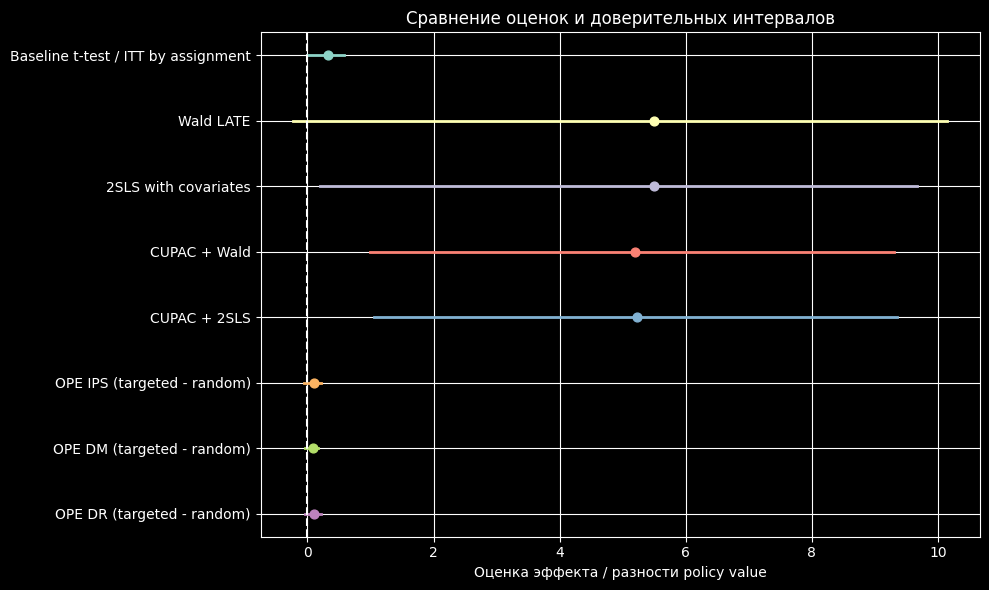

In [17]:
fig = plt.figure(figsize=(10, 6))
ypos = np.arange(len(summary))[::-1]

for i, row in summary.iterrows():
    plt.plot([row["ci_low"], row["ci_high"]], [ypos[i], ypos[i]], linewidth=2)
    plt.scatter(row["point"], ypos[i], s=40)

plt.axvline(0.0, linestyle="--")
plt.yticks(ypos, summary["approach"])
plt.title("Сравнение оценок и доверительных интервалов")
plt.xlabel("Оценка эффекта / разности policy value")
plt.tight_layout()
plt.show()


## 13. Основные выводы

In [18]:
print("1. Baseline t-test показывает, есть ли значимый ITT-эффект от самого факта назначения коммуникации.")
print("2. Wald и 2SLS оценивают LATE, то есть эффект на пользователей, которые реально принимают предложение.")
print("3. CUPAC может уменьшить дисперсию outcome и сузить доверительные интервалы.")
print("4. Поэтому возможен сценарий, где baseline незначим, а CUPAC+IV уже даёт интервал, отделимый от нуля.")
print("5. Off-policy блок не оценивает LATE; он сравнивает ценность политик назначения коммуникации.")
print("6. Для реального анализа нужно подключить точные вызовы HypEx CUPAC и OPL Policy Lab в отмеченные адаптеры.")


1. Baseline t-test показывает, есть ли значимый ITT-эффект от самого факта назначения коммуникации.
2. Wald и 2SLS оценивают LATE, то есть эффект на пользователей, которые реально принимают предложение.
3. CUPAC может уменьшить дисперсию outcome и сузить доверительные интервалы.
4. Поэтому возможен сценарий, где baseline незначим, а CUPAC+IV уже даёт интервал, отделимый от нуля.
5. Off-policy блок не оценивает LATE; он сравнивает ценность политик назначения коммуникации.
6. Для реального анализа нужно подключить точные вызовы HypEx CUPAC и OPL Policy Lab в отмеченные адаптеры.
